In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#1 Locate the working images
WORKING_DIR = Path("../data/working_images")

working_images = sorted(
    [
        p for p in WORKING_DIR.iterdir()
        if p.is_file()
        and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]
)

print("Working image directory:")
print(WORKING_DIR.resolve())

print("\nNumber of working images:", len(working_images))

print("\nFirst 10 images:")
for i, path in enumerate(working_images[:10]):
    print(i, path.name)

Working image directory:
C:\Users\nsvin\DSAI\GerrardHall3D\data\working_Images

Number of working images: 100

First 10 images:
0 IMG_2331.JPG
1 IMG_2332.JPG
2 IMG_2333.JPG
3 IMG_2334.JPG
4 IMG_2335.JPG
5 IMG_2336.JPG
6 IMG_2337.JPG
7 IMG_2338.JPG
8 IMG_2339.JPG
9 IMG_2340.JPG


In [3]:
#2 Select the first image 
image_path = working_images[0]

img = cv2.imread(str(image_path))

print("Image:", image_path.name)
print("Shape:", img.shape)

Image: IMG_2331.JPG
Shape: (936, 1404, 3)


In [4]:
#3 Run SIFT
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(
    gray,
    None
)

print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)

Number of keypoints: 9292
Descriptor shape: (9292, 128)


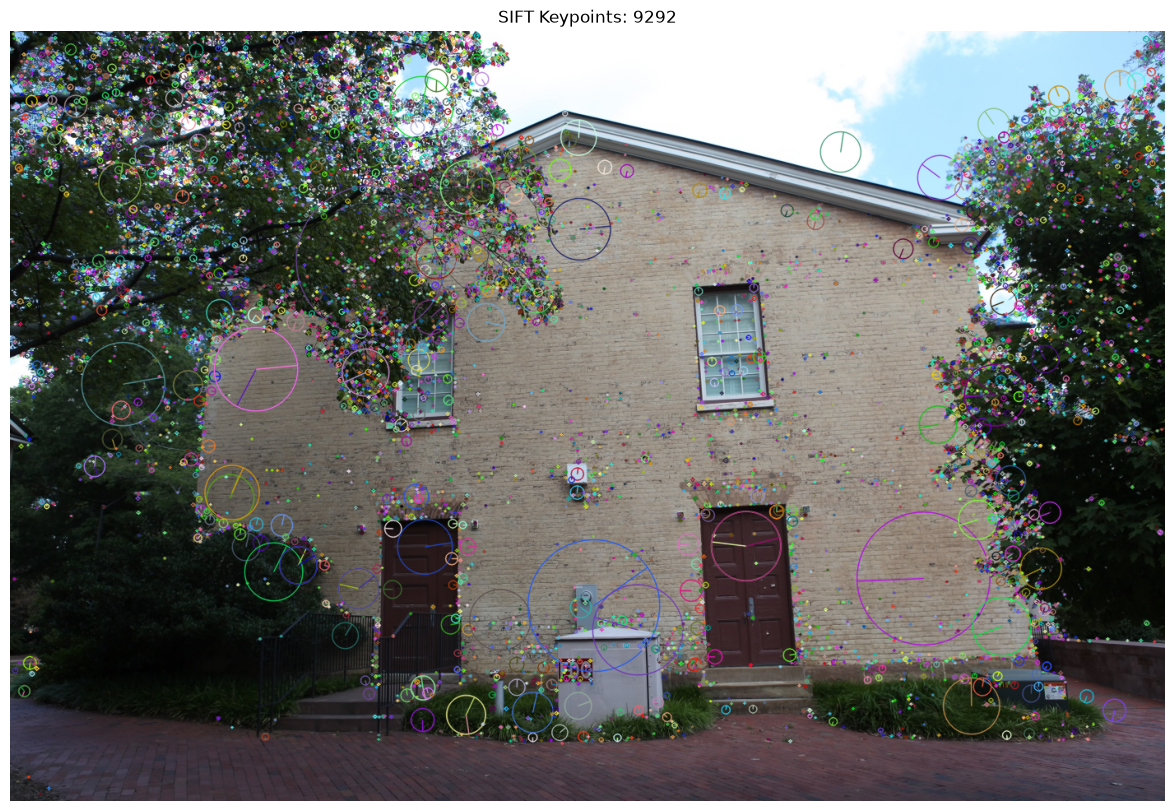

In [5]:
#4 Visualize

img_keypoints = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(16, 10))

plt.imshow(
    cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB)
)

plt.title(
    f"SIFT Keypoints: {len(keypoints)}"
)

plt.axis("off")
plt.show()

In [6]:
sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(
    gray,
    None
)

print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)

Number of keypoints: 9292
Descriptor shape: (9292, 128)


In [7]:
FEATURE_DIR = Path("../features")
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

print("Feature directory:")
print(FEATURE_DIR.resolve())

Feature directory:
C:\Users\nsvin\DSAI\GerrardHall3D\features


In [8]:
# reusable SIFT function
def extract_sift(image_path):
    """
    Read an image, convert it to grayscale,
    and extract SIFT keypoints and descriptors.
    """

    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    keypoints, descriptors = sift.detectAndCompute(
        gray,
        None
    )

    return keypoints, descriptors

In [9]:
# Test the above function
test_kp, test_des = extract_sift(
    working_images[0]
)

print("Image:", working_images[0].name)
print("Keypoints:", len(test_kp))
print("Descriptor shape:", test_des.shape)

Image: IMG_2331.JPG
Keypoints: 9292
Descriptor shape: (9292, 128)


In [10]:
# Save keypoints and descriptions

def keypoints_to_array(keypoints):
    return np.array(
        [
            [
                kp.pt[0],
                kp.pt[1],
                kp.size,
                kp.angle,
                kp.response
            ]
            for kp in keypoints
        ],
        dtype=np.float32
    )

In [11]:
kp_array = keypoints_to_array(test_kp)

print("Keypoint array shape:", kp_array.shape)

Keypoint array shape: (9292, 5)


In [12]:
#Process all 100 images

for i, image_path in enumerate(working_images):

    print(
        f"[{i+1:3d}/100] Processing {image_path.name}"
    )

    keypoints, descriptors = extract_sift(image_path)

    kp_array = keypoints_to_array(keypoints)

    stem = image_path.stem

    np.save(
        FEATURE_DIR / f"{stem}_keypoints.npy",
        kp_array
    )

    np.save(
        FEATURE_DIR / f"{stem}_descriptors.npy",
        descriptors
    )

[  1/100] Processing IMG_2331.JPG
[  2/100] Processing IMG_2332.JPG
[  3/100] Processing IMG_2333.JPG
[  4/100] Processing IMG_2334.JPG
[  5/100] Processing IMG_2335.JPG
[  6/100] Processing IMG_2336.JPG
[  7/100] Processing IMG_2337.JPG
[  8/100] Processing IMG_2338.JPG
[  9/100] Processing IMG_2339.JPG
[ 10/100] Processing IMG_2340.JPG
[ 11/100] Processing IMG_2341.JPG
[ 12/100] Processing IMG_2342.JPG
[ 13/100] Processing IMG_2343.JPG
[ 14/100] Processing IMG_2344.JPG
[ 15/100] Processing IMG_2345.JPG
[ 16/100] Processing IMG_2346.JPG
[ 17/100] Processing IMG_2347.JPG
[ 18/100] Processing IMG_2348.JPG
[ 19/100] Processing IMG_2349.JPG
[ 20/100] Processing IMG_2350.JPG
[ 21/100] Processing IMG_2351.JPG
[ 22/100] Processing IMG_2352.JPG
[ 23/100] Processing IMG_2353.JPG
[ 24/100] Processing IMG_2354.JPG
[ 25/100] Processing IMG_2355.JPG
[ 26/100] Processing IMG_2356.JPG
[ 27/100] Processing IMG_2357.JPG
[ 28/100] Processing IMG_2358.JPG
[ 29/100] Processing IMG_2359.JPG
[ 30/100] Proc

In [13]:
# Verify saved features
feature_files = sorted(FEATURE_DIR.glob("*.npy"))

print("Number of feature files:", len(feature_files))

Number of feature files: 200


In [14]:
# Inspect one saved feature set
kp_saved = np.load(
    FEATURE_DIR / "IMG_2331_keypoints.npy"
)

des_saved = np.load(
    FEATURE_DIR / "IMG_2331_descriptors.npy"
)

print("Saved keypoints:", kp_saved.shape)
print("Saved descriptors:", des_saved.shape)

Saved keypoints: (9292, 5)
Saved descriptors: (9292, 128)


In [15]:
# Find the two extra files

from collections import Counter

stems = Counter(
    f.name.rsplit("_", 1)[0]
    for f in FEATURE_DIR.glob("*.npy")
)

for stem, count in stems.items():
    if count != 2:
        print(stem, "->", count, "files")

In [16]:
# Verify the number of files
feature_files = sorted(FEATURE_DIR.glob("*.npy"))

print("Number of feature files:", len(feature_files))


Number of feature files: 200


In [17]:
print("Keypoint files:",
      len(list(FEATURE_DIR.glob("*_keypoints.npy"))))

print("Descriptor files:",
      len(list(FEATURE_DIR.glob("*_descriptors.npy"))))

Keypoint files: 100
Descriptor files: 100


# Checkpoint
Raw images                    100
Working images                100
SIFT keypoint files           100
SIFT descriptor files         100
Total feature files           200